# Portfolio Ensembles via Stacking

This notebook shows how to blend multiple portfolio specifications into a
single **ensemble allocation**. Three models -- sample mean-variance,
shrinkage mean-variance, and CVaR -- are aligned by risk percentile and
combined via both simple averaging and exposure stacking.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyvallocation import (
    assemble_portfolio_ensemble,
    make_portfolio_spec,
)

## Load return data

We use the last 750 daily returns from the bundled ETF prices.

In [2]:
from pathlib import Path

_candidates = [
    Path("examples/ETF_prices.csv"),
    Path("../examples/ETF_prices.csv"),
    Path("../../examples/ETF_prices.csv"),
    Path("../../../examples/ETF_prices.csv"),
]
_csv = next((p for p in _candidates if p.exists()), None)
if _csv is None:
    raise FileNotFoundError("ETF_prices.csv not found")
prices = pd.read_csv(_csv, index_col="Date", parse_dates=True)
prices = prices.dropna(how="all").ffill()
returns = prices.pct_change().dropna(how="any").iloc[-750:]

print(f"Assets : {list(returns.columns)}")
print(f"Periods: {len(returns)}")

Assets : ['DBC', 'GLD', 'SPY', 'TLT']
Periods: 750


## Define three portfolio specifications

Each spec uses a different model but is aligned at the **median risk percentile**
so that the selected portfolios are comparable:

1. **Sample MV** -- sample mean and covariance.
2. **Shrinkage MV** -- Jorion mean + Ledoit-Wolf covariance.
3. **CVaR** -- scenario-based CVaR at alpha=5%.

In [3]:
selector_kwargs = {"percentile": 0.5, "risk_label": "Volatility"}

specs = [
    make_portfolio_spec(
        "Sample MV",
        returns=returns,
        mean_estimator="sample",
        cov_estimator="sample",
        optimiser="mean_variance",
        selector="risk_percentile",
        selector_kwargs=selector_kwargs,
    ),
    make_portfolio_spec(
        "Shrinkage MV",
        returns=returns,
        mean_estimator="jorion",
        cov_estimator="ledoit_wolf",
        optimiser="mean_variance",
        selector="risk_percentile",
        selector_kwargs=selector_kwargs,
    ),
]

In [4]:
specs.append(
    make_portfolio_spec(
        "CVaR",
        returns=returns,
        use_scenarios=True,
        optimiser="cvar",
        optimiser_kwargs={"alpha": 0.05},
        selector="risk_percentile",
        selector_kwargs=selector_kwargs,
    ),
)

print(f"Defined {len(specs)} specs: {[s.name for s in specs]}")

Defined 3 specs: ['Sample MV', 'Shrinkage MV', 'CVaR']


## Assemble the ensemble

`assemble_portfolio_ensemble` runs each spec, selects portfolios at the
target risk percentile, and combines them via averaging and stacking.

In [5]:
result = assemble_portfolio_ensemble(
    specs,
    ensemble=("average", "stack"),
    combine="selected",
)

No constraints set; using default long-only, fully-invested.


No constraints set; using default long-only, fully-invested.


Estimating mu and cov from scenarios (no explicit values provided).


No constraints set; using default long-only, fully-invested.


## Print stacked vs averaged weights

In [6]:
print("=== Selected portfolios (aligned by risk percentile) ===")
print(result.selections.round(4))

print("\n=== Ensemble portfolios ===")
for name, w in result.ensembles.items():
    print(f"\n[{name}]")
    print(w.round(4))

=== Selected portfolios (aligned by risk percentile) ===
     Sample MV  Shrinkage MV    CVaR
DBC     0.1026        0.1027  0.0000
GLD     0.4400        0.4399  0.5327
SPY     0.2782        0.2781  0.2526
TLT     0.1793        0.1792  0.2147

=== Ensemble portfolios ===

[average]
DBC    0.0684
GLD    0.4709
SPY    0.2696
TLT    0.1911
Name: Average Exposure, dtype: float64

[stack]
DBC    0.0745
GLD    0.4654
SPY    0.2711
TLT    0.1890
Name: Exposure Stacking (L=3), dtype: float64


## Compare ensemble weights visually

A grouped bar chart highlights how stacking dampens idiosyncratic tilts
compared to simple averaging.

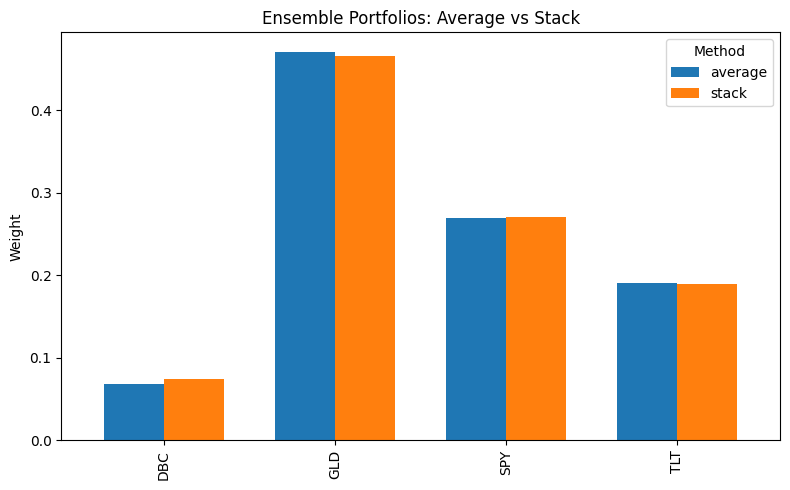

In [7]:
ensemble_df = pd.DataFrame(
    {name: w for name, w in result.ensembles.items()}
)

fig, ax = plt.subplots(figsize=(8, 5))
ensemble_df.plot.bar(ax=ax, width=0.7)
ax.set_ylabel("Weight")
ax.set_title("Ensemble Portfolios: Average vs Stack")
ax.legend(title="Method")
fig.tight_layout()
plt.show()